In [2]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/sagnikpatra/uci-adult-census-data-dataset/adult_train.csv
/kaggle/input/datasets/sagnikpatra/uci-adult-census-data-dataset/adult_test.csv
/kaggle/input/datasets/zerotrace11/tech-company-dataset/tech_company_employee_data_1000.csv
/kaggle/input/datasets/shree1992/housedata/output.csv
/kaggle/input/datasets/shree1992/housedata/data.csv
/kaggle/input/datasets/shree1992/housedata/data.dat
/kaggle/input/datasets/lovishbansal123/titanic-dataset/Titanic-Dataset.csv
/kaggle/input/datasets/iammustafatz/diabetes-prediction-dataset/diabetes_prediction_dataset.csv


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
uci = pd.read_csv('/kaggle/input/datasets/sagnikpatra/uci-adult-census-data-dataset/adult_train.csv')
diabetes = pd.read_csv('/kaggle/input/datasets/iammustafatz/diabetes-prediction-dataset/diabetes_prediction_dataset.csv')
titanic = pd.read_csv('/kaggle/input/datasets/lovishbansal123/titanic-dataset/Titanic-Dataset.csv')
house = pd.read_csv('/kaggle/input/datasets/shree1992/housedata/data.csv')

# impute missing values of occupation column of uci dataset

In [5]:
uci

,Age,Workclass,fnlwgt,Education,Education_Num,Martial_Status,Occupation,Relationship,Race,Sex,Capital_Gain,Capital_Loss,Hours_per_week,Country,Target
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [6]:
print("Missing values before imputation:")
print(uci['Occupation'].isnull().sum())

Missing values before imputation:
1843


In [7]:
replaced_by=uci['Occupation'].mode()[0]
uci['Occupation']=uci['Occupation'].fillna(replaced_by)
print("Missing value after imputatiom",uci['Occupation'].isnull().sum())

Missing value after imputatiom 0


# Outliers

# 1. find and mitigate(trimming and capping both) outliers on age column of diabetes dataset

In [8]:
print(diabetes['age'].describe())

count    100000.000000
mean         41.885856
std          22.516840
min           0.080000
25%          24.000000
50%          43.000000
75%          60.000000
max          80.000000
Name: age, dtype: float64


In [10]:
print("Skewness:",diabetes['age'].skew())


Skewness: -0.05197899678256747


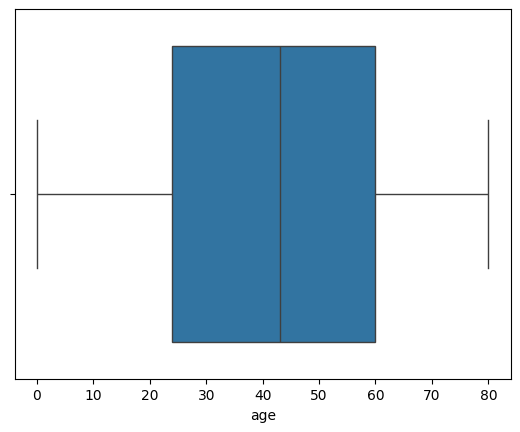

In [11]:
sns.boxplot(x=diabetes['age'])
plt.show()

# Age Column Mean & Std 

In [16]:
mean_age = diabetes['age'].mean()
std_age = diabetes['age'].std()
print("Mean age:", mean_age)
print("Standard deviation:", std_age)

Mean age: 41.885856
Standard deviation: 22.51683987161513


# Calculate Upper & Lower Limit

In [20]:
upper_limit = mean_age + 3*std_age
lower_limit = mean_age + 3*std_age
x = max(lower_limit,0)
print("Upper limit:", upper_limit)
print("Lower limit:", x)

Upper limit: 109.43637561484539
Lower limit: 109.43637561484539


# Find Outliers

In [21]:
age_outliers = diabetes[(diabetes['age'] > upper_limit) |
                         (diabetes['age'] < lower_limit)
                    ]
print("Number of Outliers:",len(age_outliers))

age_outliers

Number of Outliers: 100000


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0
...,...,...,...,...,...,...,...,...,...
99995,Female,80.0,0,0,No Info,27.32,6.2,90,0
99996,Female,2.0,0,0,No Info,17.37,6.5,100,0
99997,Male,66.0,0,0,former,27.83,5.7,155,0
99998,Female,24.0,0,0,never,35.42,4.0,100,0


# Trimming the age outliers

In [28]:
age_trim = diabetes[
   (diabetes['age'] < upper_limit) &
    (diabetes['age'] >lower_limit)
]
age_trim


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes


# Shape Checking Before and After triming

In [30]:
print("Original shape:", diabetes.shape)
print("After trimming:", age_trim.shape)

Original shape: (100000, 9)
After trimming: (0, 9)


In [37]:
age_capped = diabetes.copy()

# Capping the age outliers

In [38]:
age_capped['age'] = np.where(
   age_capped['age'] > upper_limit,
    upper_limit,
    np.where(
        age_capped['age'] < lower_limit,
        lower_limit,
       age_capped['age']
    )
)


In [40]:
print("Original shape:", diabetes.shape)
print("After capping:", age_capped.shape)

Original shape: (100000, 9)
After capping: (100000, 9)


In [41]:
print("Original:", diabetes.shape)
print("Trimmed:", age_trim.shape)
print("Capped:", age_capped.shape)

Original: (100000, 9)
Trimmed: (0, 9)
Capped: (100000, 9)


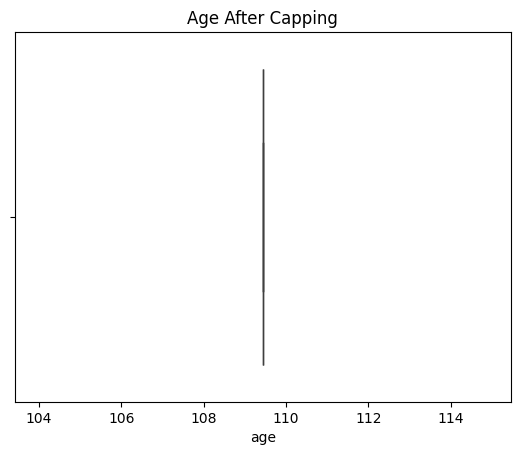

In [43]:
sns.boxplot(x=age_capped['age'])
plt.title("Age After Capping")
plt.show()

# 2. find and mitigate(trimming and capping both) outliers on price column of house dataset

In [45]:
house

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,3.130000e+05,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2.384000e+06,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,3.420000e+05,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,4.200000e+05,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,5.500000e+05,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4595,2014-07-09 00:00:00,3.081667e+05,3.0,1.75,1510,6360,1.0,0,0,4,1510,0,1954,1979,501 N 143rd St,Seattle,WA 98133,USA
4596,2014-07-09 00:00:00,5.343333e+05,3.0,2.50,1460,7573,2.0,0,0,3,1460,0,1983,2009,14855 SE 10th Pl,Bellevue,WA 98007,USA
4597,2014-07-09 00:00:00,4.169042e+05,3.0,2.50,3010,7014,2.0,0,0,3,3010,0,2009,0,759 Ilwaco Pl NE,Renton,WA 98059,USA
4598,2014-07-10 00:00:00,2.034000e+05,4.0,2.00,2090,6630,1.0,0,0,3,1070,1020,1974,0,5148 S Creston St,Seattle,WA 98178,USA


In [44]:
print(house['price'].describe())

count    4.600000e+03
mean     5.519630e+05
std      5.638347e+05
min      0.000000e+00
25%      3.228750e+05
50%      4.609435e+05
75%      6.549625e+05
max      2.659000e+07
Name: price, dtype: float64


In [46]:
print("Skewness:", house['price'].skew())

Skewness: 24.790932561757053


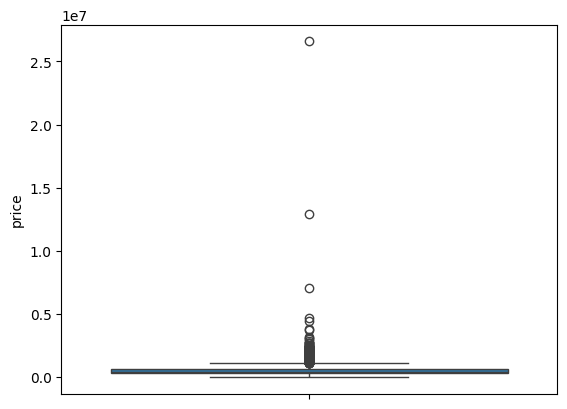

In [48]:
sns.boxplot(y=house['price'])
plt.show()

# Calculate Q1, Q3 and IQR

In [49]:
Q1 = house['price'].quantile(0.25)
Q3 = house['price'].quantile(0.75)
IQR = Q3 - Q1
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

Q1: 322875.0
Q3: 654962.5
IQR: 332087.5


# Caluculate limit

In [50]:
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR
print("Lower limit:", lower_limit)
print("Upper limit:", upper_limit)

Lower limit: -175256.25
Upper limit: 1153093.75


# Find price outliers

In [51]:
price_outliers = house[
    (house['price'] < lower_limit) |
    (house['price'] > upper_limit)
]
print("Number of price outliers:", len(price_outliers))
price_outliers

Number of price outliers: 240


,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
1,2014-05-02 00:00:00,2.384000e+06,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
11,2014-05-02 00:00:00,1.400000e+06,4.0,2.50,2920,4000,1.5,0,0,5,1910,1010,1909,1988,3838-4098 44th Ave NE,Seattle,WA 98105,USA
14,2014-05-02 00:00:00,1.200000e+06,5.0,2.75,2910,9480,1.5,0,0,3,2910,0,1939,1969,3534 46th Ave NE,Seattle,WA 98105,USA
99,2014-05-05 00:00:00,1.395000e+06,5.0,3.50,4010,8510,2.0,0,1,5,2850,1160,1971,0,3930 NE Belvoir Pl,Seattle,WA 98105,USA
122,2014-05-05 00:00:00,2.280000e+06,7.0,8.00,13540,307752,3.0,0,4,3,9410,4130,1999,0,26408 NE 70th St,Redmond,WA 98053,USA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4348,2014-05-05 00:00:00,2.199900e+06,4.0,1.50,1120,5427,1.0,0,0,3,1120,0,1969,2014,19009-19021 SE 266th St,Covington,WA 98042,USA
4350,2014-07-03 00:00:00,2.659000e+07,3.0,2.00,1180,7793,1.0,0,0,4,1180,0,1992,0,12005 SE 219th Ct,Kent,WA 98031,USA
4465,2014-06-05 00:00:00,2.560498e+06,3.0,2.50,1710,1664,2.0,0,0,5,1300,410,2003,0,2826 21st Ave W,Seattle,WA 98199,USA
4467,2014-06-06 00:00:00,1.337044e+06,4.0,3.50,4280,9583,2.0,0,0,3,4280,0,2005,0,1415 108th Ave SE,Bellevue,WA 98004,USA


# Trimming house-price outliers

In [53]:
house_price_trimmed = house[
    (house['price'] >= lower_limit) &
    (house['price'] <= upper_limit)
]
house_price_trimmed

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.000000,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
2,2014-05-02 00:00:00,342000.000000,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.000000,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.000000,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA
5,2014-05-02 00:00:00,490000.000000,2.0,1.00,880,6380,1.0,0,0,3,880,0,1938,1994,522 NE 88th St,Seattle,WA 98115,USA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4595,2014-07-09 00:00:00,308166.666667,3.0,1.75,1510,6360,1.0,0,0,4,1510,0,1954,1979,501 N 143rd St,Seattle,WA 98133,USA
4596,2014-07-09 00:00:00,534333.333333,3.0,2.50,1460,7573,2.0,0,0,3,1460,0,1983,2009,14855 SE 10th Pl,Bellevue,WA 98007,USA
4597,2014-07-09 00:00:00,416904.166667,3.0,2.50,3010,7014,2.0,0,0,3,3010,0,2009,0,759 Ilwaco Pl NE,Renton,WA 98059,USA
4598,2014-07-10 00:00:00,203400.000000,4.0,2.00,2090,6630,1.0,0,0,3,1070,1020,1974,0,5148 S Creston St,Seattle,WA 98178,USA


In [54]:
house_price_trimmed[
    (house_price_trimmed['price'] < lower_limit) |
    (house_price_trimmed['price'] > upper_limit)
].shape

(0, 18)

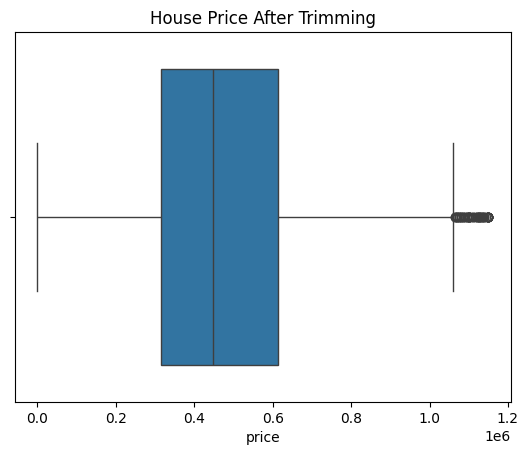

In [56]:
sns.boxplot(x=house_price_trimmed['price'])
plt.title("House Price After Trimming")
plt.show()

# Capping house-price outliers

In [57]:
house_price_capped = house.copy()

In [58]:
house_price_capped['price'] = np.where(
    house_price_capped['price'] > upper_limit,
    upper_limit,
    np.where(
        house_price_capped['price'] < lower_limit,
        lower_limit,
        house_price_capped['price']
    )
)

In [59]:
print("Original shape:", house.shape)
print("After capping:", house_price_capped.shape)

Original shape: (4600, 18)
After capping: (4600, 18)


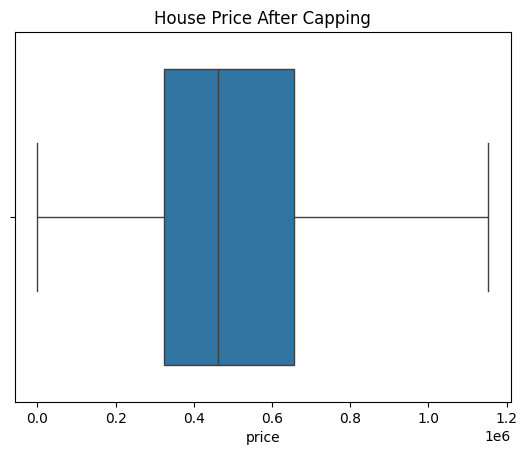

In [62]:
sns.boxplot(x=house_price_capped['price'])
plt.title("House Price After Capping")
plt.show()